# Extrinsic Analysis: MMLU Results - Adapter Comparison by Model

This notebook analyzes MMLU (Massive Multitask Language Understanding) results comparing different adapters across three models:
- **Llama-3.2-3B-Instruct** (llama-3b)
- **Llama-3.1-8B-Instruct** (llama-8b)
- **Gemma-3-12B** (gemma-12b)

## Key Analysis
For each model, we compare adapter performance (LoRA, VeRA, UIOrthoLoRA, RandLoRA) across different learning rates, averaged over all training samples.

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Data Loading and Preprocessing

In [2]:
# Define path to data
DATA_PATH = Path('../results/mmlu/mmlu_summary.csv')

# Load the data
df = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df)} rows")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loaded 10 rows

Columns: ['model_name', 'mmlu_acc', 'mmlu_acc_stderr', 'mmlu_humanities_acc', 'mmlu_other_acc', 'mmlu_social_sciences_acc', 'mmlu_stem_acc', 'json_path']

First few rows:


,model_name,mmlu_acc,mmlu_acc_stderr,mmlu_humanities_acc,mmlu_other_acc,mmlu_social_sciences_acc,mmlu_stem_acc,json_path
0,models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4,0.709087,0.003588,0.634644,0.764725,0.816055,0.660958,google_gemma-3-12b-it_vera_trAll_lr1e-4/models__google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4/results_2026-01-17T00-28-45.521921.json
1,models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-5,0.709087,0.003589,0.635494,0.762150,0.815405,0.662861,google_gemma-3-12b-it_vera_trAll_lr7e-5/models__google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-5/results_2026-01-17T06-20-57.502280.json
2,models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-5,0.708375,0.003597,0.635282,0.761506,0.812480,0.663495,google_gemma-3-12b-it_uiortholora_trAll_lr7e-5/models__google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-5/results_2026-01-17T06-40-34.106881.json
3,models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-4,0.707520,0.003599,0.636344,0.760219,0.811830,0.660006,google_gemma-3-12b-it_uiortholora_trAll_lr1e-4/models__google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-4/results_2026-01-17T00-43-44.436401.json
4,models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-4,0.706666,0.003597,0.632731,0.761828,0.814430,0.657469,google_gemma-3-12b-it_uiortholora_trAll_lr5e-4/models__google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-4/results_2026-01-17T12-09-23.997328.json


## Extract Information from Model Names

In [3]:
def parse_model_name(model_name):
    """
    Parse model name to extract key information.
    
    Example: 'models/meta-llama_Llama-3.1-8B-Instruct_lora_tr100_lora_r3_lr1e-5'
    Returns: {'adapter': 'lora', 'tr': 100, 'lr': '1e-5', 'model': 'llama-8b'}
    """
    result = {}
    
    # Extract model base name
    if 'Llama-3.2-3B' in model_name:
        result['model'] = 'llama-3b'
        result['model_full'] = 'Llama-3.2-3B'
    elif 'Llama-3.1-8B' in model_name:
        result['model'] = 'llama-8b'
        result['model_full'] = 'Llama-3.1-8B'
    elif 'gemma-3-12b' in model_name or 'gemma-2-12b' in model_name:
        result['model'] = 'gemma-12b'
        result['model_full'] = 'Gemma-3-12B'
    else:
        result['model'] = 'unknown'
        result['model_full'] = 'Unknown'
    
    # Extract adapter type
    adapter_pattern = r'_(lora|vera|uiortholora|randlora)_tr'
    adapter_match = re.search(adapter_pattern, model_name)
    if adapter_match:
        result['adapter'] = adapter_match.group(1)
    else:
        result['adapter'] = 'unknown'
    
    # Extract training samples (tr)
    tr_pattern = r'_tr(\d+)_'
    tr_match = re.search(tr_pattern, model_name)
    if tr_match:
        result['tr'] = int(tr_match.group(1))
    else:
        result['tr'] = None
    
    # Extract learning rate (lr)
    lr_pattern = r'_lr(\d+e-\d+)'
    lr_match = re.search(lr_pattern, model_name)
    if lr_match:
        result['lr'] = lr_match.group(1)
    else:
        result['lr'] = 'unknown'
    
    return result

# Apply parsing function
parsed_info = df['model_name'].apply(parse_model_name)
df_parsed = pd.DataFrame(parsed_info.tolist())

# Combine with original dataframe
df_combined = pd.concat([df, df_parsed], axis=1)

# Display sample
print("Parsed information:")
print(df_combined[['model_name', 'model', 'adapter', 'tr', 'lr', 'mmlu_acc']].head(10))
print(f"\nUnique models found: {sorted(df_combined['model'].unique())}")
print(f"Unique adapters found: {sorted(df_combined['adapter'].unique())}")
print(f"Unique learning rates found: {sorted(df_combined['lr'].unique())}")

Parsed information:
                                                                   model_name  \
0                   models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr1e-4   
1                   models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr7e-5   
2  models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr7e-5   
3  models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr1e-4   
4  models/google_gemma-3-12b-it_uiortholora_trAll_uiortholora_s1024_v0_lr5e-4   
5                   models/google_gemma-3-12b-it_vera_trAll_vera_r1024_lr5e-4   
6                      models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-5   
7                      models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4   
8                      models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr7e-4   
9                      models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr5e-4   

       model      adapter    tr    lr  mmlu_acc  
0  gemma-12b         vera  None  1e-4 

## Data Summary by Model

In [4]:
print("Data distribution by model:")
print(df_combined['model'].value_counts())
print("\nData distribution by model and adapter:")
print(df_combined.groupby(['model', 'adapter']).size())
print("\nData distribution by model and learning rate:")
print(df_combined.groupby(['model', 'lr']).size())

Data distribution by model:
model
gemma-12b    10
Name: count, dtype: int64

Data distribution by model and adapter:
model      adapter    
gemma-12b  lora           4
           uiortholora    3
           vera           3
dtype: int64

Data distribution by model and learning rate:
model      lr  
gemma-12b  1e-4    3
           5e-4    3
           7e-4    1
           7e-5    3
dtype: int64


## Main Analysis: Average Accuracy per Adapter and Learning Rate for Each Model

Calculate the average MMLU accuracy for each adapter type across all training samples, grouped by model and learning rate.

In [8]:
# Group by model, adapter, and learning rate, calculate mean accuracy
avg_acc_by_model_adapter_lr = df_combined.groupby(['model', 'model_full', 'adapter', 'lr']).agg({
    'mmlu_acc': ['mean', 'std', 'count'],
    'mmlu_humanities_acc': 'mean',
    'mmlu_other_acc': 'mean',
    'mmlu_social_sciences_acc': 'mean',
    'mmlu_stem_acc': 'mean'
}).round(4)

# Flatten column names
avg_acc_by_model_adapter_lr.columns = ['_'.join(col).strip() if col[1] else col[0] 
                                        for col in avg_acc_by_model_adapter_lr.columns.values]
avg_acc_by_model_adapter_lr = avg_acc_by_model_adapter_lr.reset_index()

# Rename for clarity
avg_acc_by_model_adapter_lr.rename(columns={
    'mmlu_acc_mean': 'avg_mmlu_acc',
    'mmlu_acc_stderr': 'std_mmlu_acc',
    'mmlu_acc_count': 'num_experiments'
}, inplace=True)

print("Average MMLU Accuracy by Model, Adapter, and Learning Rate:")
print("="*100)
print(avg_acc_by_model_adapter_lr.sort_values(['model', 'lr', 'avg_mmlu_acc'], ascending=[True, True, False]))
print("\n" + "="*100)

Average MMLU Accuracy by Model, Adapter, and Learning Rate:
       model   model_full      adapter    lr  avg_mmlu_acc  mmlu_acc_std  \
7  gemma-12b  Gemma-3-12B         vera  1e-4        0.7091           NaN   
4  gemma-12b  Gemma-3-12B  uiortholora  1e-4        0.7075           NaN   
0  gemma-12b  Gemma-3-12B         lora  1e-4        0.6911           NaN   
5  gemma-12b  Gemma-3-12B  uiortholora  5e-4        0.7067           NaN   
8  gemma-12b  Gemma-3-12B         vera  5e-4        0.7051           NaN   
1  gemma-12b  Gemma-3-12B         lora  5e-4        0.2426           NaN   
2  gemma-12b  Gemma-3-12B         lora  7e-4        0.2460           NaN   
9  gemma-12b  Gemma-3-12B         vera  7e-5        0.7091           NaN   
6  gemma-12b  Gemma-3-12B  uiortholora  7e-5        0.7084           NaN   
3  gemma-12b  Gemma-3-12B         lora  7e-5        0.6990           NaN   

   num_experiments  mmlu_humanities_acc_mean  mmlu_other_acc_mean  \
7                1                

## Visualization 3: Effect of Training Samples per Model

Analyze how performance scales with training samples for each model.

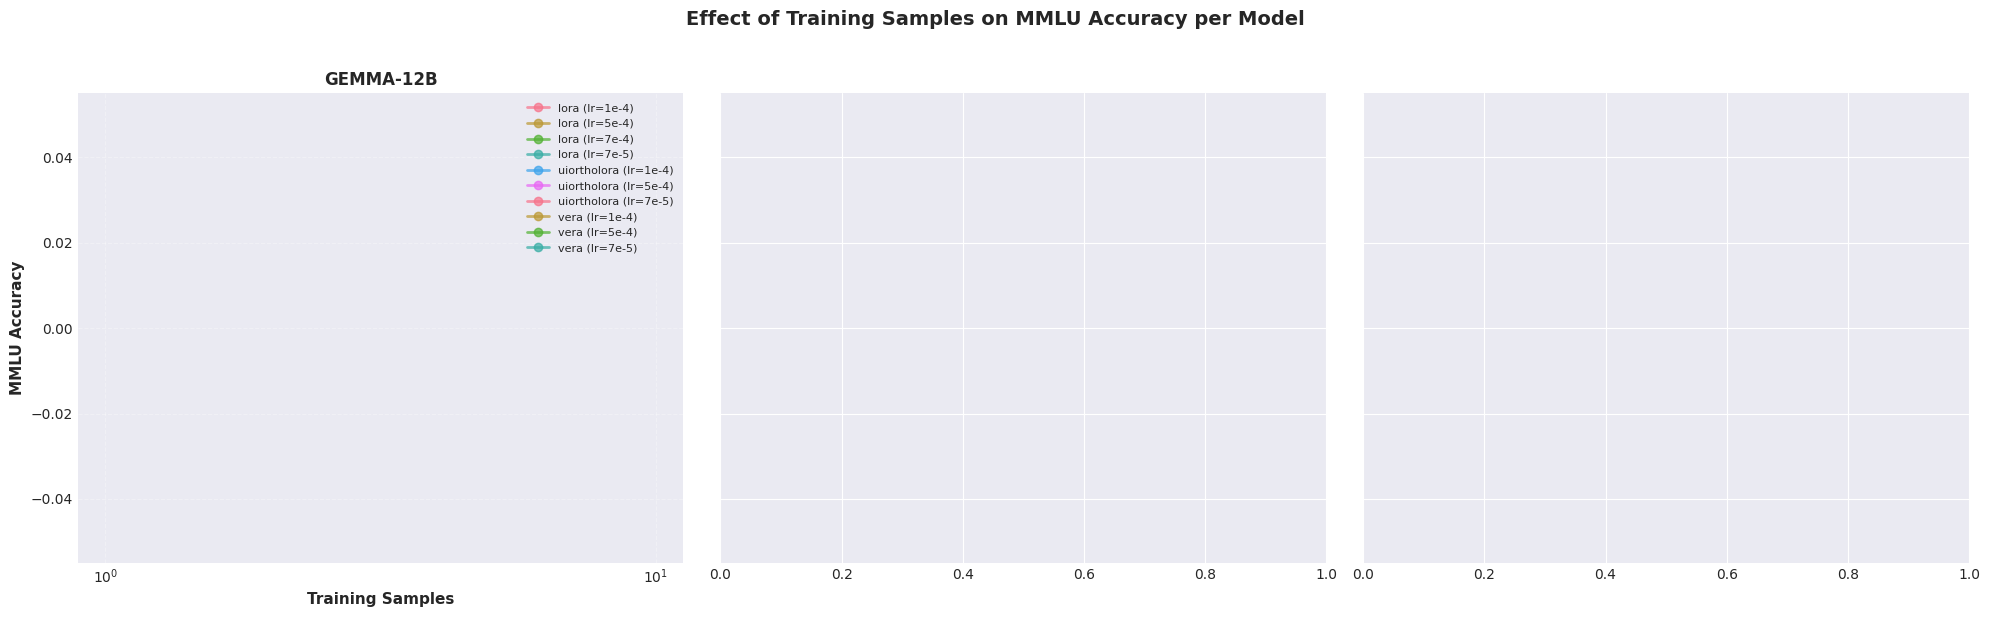


Correlation between training samples and accuracy per model:
gemma-12b    | Correlation: +nan


In [6]:
# Create 3 plots, one for each model showing effect of training samples
models = sorted(df_combined['model'].unique())
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for model_idx, model in enumerate(models):
    ax = axes[model_idx]
    model_data = df_combined[df_combined['model'] == model]
    
    # Plot each adapter-lr combination
    for adapter in sorted(model_data['adapter'].unique()):
        adapter_data = model_data[model_data['adapter'] == adapter]
        
        # Group by tr and lr, taking the mean if there are duplicates
        for lr in sorted(adapter_data['lr'].unique()):
            lr_adapter_data = adapter_data[adapter_data['lr'] == lr].sort_values('tr')
            if len(lr_adapter_data) > 0:
                # Group by tr to handle potential duplicates
                grouped = lr_adapter_data.groupby('tr')['mmlu_acc'].mean().reset_index()
                ax.plot(grouped['tr'], grouped['mmlu_acc'], 
                       marker='o', label=f'{adapter} (lr={lr})', 
                       linewidth=2, markersize=6, alpha=0.7)
    
    ax.set_xlabel('Training Samples', fontsize=11, fontweight='bold')
    ax.set_title(f'{model.upper()}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, loc='best')
    ax.set_xscale('log')

axes[0].set_ylabel('MMLU Accuracy', fontsize=11, fontweight='bold')
fig.suptitle('Effect of Training Samples on MMLU Accuracy per Model', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('graphs/training_samples_effect_per_model.png', dpi=300, bbox_inches='tight')
plt.show()

# Show correlation between training samples and accuracy for each model
print("\nCorrelation between training samples and accuracy per model:")
print("="*80)
for model in models:
    model_data = df_combined[df_combined['model'] == model]
    corr = model_data[['tr', 'mmlu_acc']].corr().iloc[0, 1]
    print(f"{model:12s} | Correlation: {corr:+.4f}")

In [ ]:
stop

## Visualization 4: Overall Model Performance Summary

In [9]:
print("="*100)
print("STATISTICAL SUMMARY BY MODEL")
print("="*100)

for model in models:
    print(f"\n{'='*100}")
    print(f"MODEL: {model_full_names[model]}")
    print(f"{'='*100}")
    
    model_data = df_combined[df_combined['model'] == model]
    model_avg_data = avg_acc_by_model_adapter_lr[avg_acc_by_model_adapter_lr['model'] == model]
    
    # Best overall configuration for this model
    print("\n1. Top 5 Configurations (adapter + lr combination):")
    print("-" * 100)
    top_5 = model_avg_data.nlargest(5, 'avg_mmlu_acc')[['adapter', 'lr', 'avg_mmlu_acc', 'std_mmlu_acc', 'num_experiments']]
    for idx, row in top_5.iterrows():
        print(f"   {row['adapter']:15s} | lr={row['lr']:8s} | avg_acc={row['avg_mmlu_acc']:.4f} ± {row['std_mmlu_acc']:.4f} (n={int(row['num_experiments'])})") 
    
    # Best adapter (averaged across all configurations)
    print("\n2. Best Adapter (averaged across all lr and tr):")
    print("-" * 100)
    adapter_avg = model_data.groupby('adapter')['mmlu_acc'].agg(['mean', 'std', 'max']).round(4)
    adapter_avg = adapter_avg.sort_values('mean', ascending=False)
    for adapter, row in adapter_avg.iterrows():
        print(f"   {adapter:15s} | mean={row['mean']:.4f} | std={row['std']:.4f} | max={row['max']:.4f}")
    
    # Best learning rate (averaged across all configurations)
    print("\n3. Best Learning Rate (averaged across all adapters and tr):")
    print("-" * 100)
    lr_avg = model_data.groupby('lr')['mmlu_acc'].agg(['mean', 'std']).round(4)
    lr_avg = lr_avg.sort_values('mean', ascending=False)
    for lr, row in lr_avg.iterrows():
        print(f"   lr={lr:8s} | mean={row['mean']:.4f} | std={row['std']:.4f}")

print("\n" + "="*100)

STATISTICAL SUMMARY BY MODEL

MODEL: Gemma-3-12B

1. Top 5 Configurations (adapter + lr combination):
----------------------------------------------------------------------------------------------------
   uiortholora     | lr=1e-5     | avg_acc=0.7153 ± 0.0002 (n=7)
   vera            | lr=1e-5     | avg_acc=0.7149 ± 0.0005 (n=7)
   lora            | lr=1e-5     | avg_acc=0.7143 ± 0.0036 (n=14)
   uiortholora     | lr=1e-4     | avg_acc=0.7140 ± 0.0018 (n=7)
   vera            | lr=1e-4     | avg_acc=0.7132 ± 0.0042 (n=7)

2. Best Adapter (averaged across all lr and tr):
----------------------------------------------------------------------------------------------------
   uiortholora     | mean=0.7128 | std=0.0035 | max=0.7159
   vera            | mean=0.7120 | std=0.0043 | max=0.7211
   randlora        | mean=0.6987 | std=0.0194 | max=0.7154
   lora            | mean=0.5791 | std=0.1895 | max=0.7214

3. Best Learning Rate (averaged across all adapters and tr):
----------------------

## Visualization 5: Best Configuration per Model

In [10]:
print("="*100)
print("CROSS-MODEL COMPARISON")
print("="*100)

# Best adapter-lr combination for each model
print("\nBest Adapter-LR Combination per Model:")
print("-" * 100)
for model in models:
    model_avg_data = avg_acc_by_model_adapter_lr[avg_acc_by_model_adapter_lr['model'] == model]
    best = model_avg_data.loc[model_avg_data['avg_mmlu_acc'].idxmax()]
    print(f"{model_full_names[model]:20s} | {best['adapter']:15s} | lr={best['lr']:8s} | acc={best['avg_mmlu_acc']:.4f} ± {best['std_mmlu_acc']:.4f}")

# Overall model performance (averaged across all configurations)
print("\nOverall Model Performance (averaged across all adapters, lr, and tr):")
print("-" * 100)
model_overall = df_combined.groupby('model')['mmlu_acc'].agg(['mean', 'std', 'max', 'count']).round(4)
model_overall = model_overall.sort_values('mean', ascending=False)
for model, row in model_overall.iterrows():
    print(f"{model_full_names[model]:20s} | mean={row['mean']:.4f} | std={row['std']:.4f} | max={row['max']:.4f} | n={int(row['count'])}")

print("\n" + "="*100)

CROSS-MODEL COMPARISON

Best Adapter-LR Combination per Model:
----------------------------------------------------------------------------------------------------
Gemma-3-12B          | uiortholora     | lr=1e-5     | acc=0.7153 ± 0.0002
Llama-3.2-3B         | uiortholora     | lr=1e-3     | acc=0.6253 ± 0.0019
Llama-3.1-8B         | uiortholora     | lr=1e-5     | acc=0.6843 ± 0.0007

Overall Model Performance (averaged across all adapters, lr, and tr):
----------------------------------------------------------------------------------------------------
Gemma-3-12B          | mean=0.6563 | std=0.1352 | max=0.7214 | n=105
Llama-3.1-8B         | mean=0.6463 | std=0.1075 | max=0.6852 | n=82
Llama-3.2-3B         | mean=0.5955 | std=0.0734 | max=0.6276 | n=84



## Heatmaps: Model × (Adapter × LR)

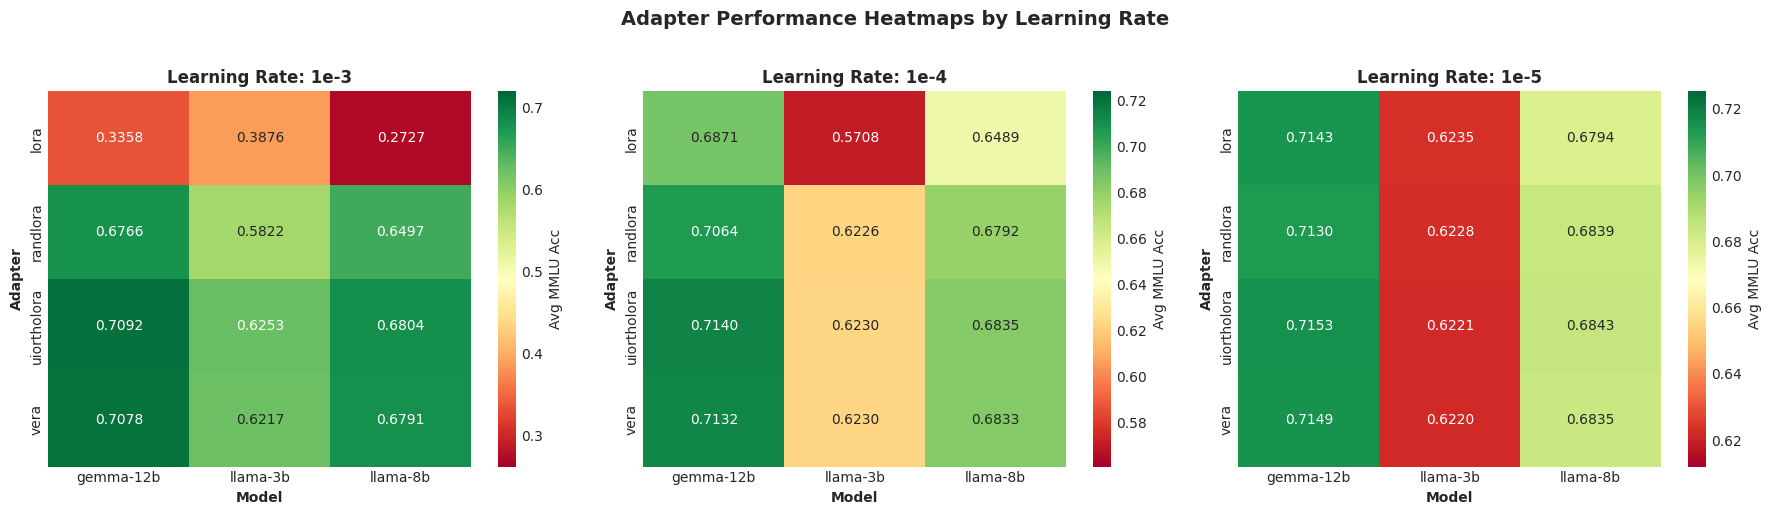

In [11]:
# Create heatmaps showing adapter performance for each learning rate
learning_rates = sorted(avg_acc_by_model_adapter_lr['lr'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    lr_data = avg_acc_by_model_adapter_lr[avg_acc_by_model_adapter_lr['lr'] == lr]
    
    # Create pivot table
    pivot = lr_data.pivot(index='adapter', columns='model', values='avg_mmlu_acc')
    pivot = pivot[models]  # Sort columns by model order
    
    # Compute vmin and vmax
    valid_values = pivot.values[~np.isnan(pivot.values)]
    if len(valid_values) > 0:
        vmin = valid_values.min() - 0.01
        vmax = valid_values.max() + 0.01
    else:
        vmin, vmax = None, None
    
    # Create heatmap
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', 
                cbar_kws={'label': 'Avg MMLU Acc'},
                vmin=vmin, vmax=vmax, ax=ax)
    
    ax.set_title(f'Learning Rate: {lr}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=10, fontweight='bold')
    ax.set_ylabel('Adapter', fontsize=10, fontweight='bold')

fig.suptitle('Adapter Performance Heatmaps by Learning Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graphs/heatmap_adapter_by_model_lr.png', dpi=300, bbox_inches='tight')
plt.show()

## Export Summary Results

In [12]:
# Export the main analysis results to CSV
output_path = Path('results_summary')
output_path.mkdir(exist_ok=True)

# Save average accuracy by model, adapter, and lr
avg_acc_by_model_adapter_lr.to_csv(output_path / 'avg_accuracy_by_model_adapter_lr.csv', index=False)
print(f"Saved: {output_path / 'avg_accuracy_by_model_adapter_lr.csv'}")

# Save best configuration for each model
best_per_model = []
for model in models:
    model_data = avg_acc_by_model_adapter_lr[avg_acc_by_model_adapter_lr['model'] == model]
    best = model_data.loc[model_data['avg_mmlu_acc'].idxmax()]
    best_per_model.append(best)

best_per_model_df = pd.DataFrame(best_per_model)
best_per_model_df.to_csv(output_path / 'best_config_per_model.csv', index=False)
print(f"Saved: {output_path / 'best_config_per_model.csv'}")

print("\nAll results exported successfully!")

Saved: results_summary/avg_accuracy_by_model_adapter_lr.csv
Saved: results_summary/best_config_per_model.csv

All results exported successfully!


## Key Findings

This analysis compares adapter performance across three models:

1. **Model-Specific Insights**: Each model shows different optimal adapter-lr combinations
2. **Adapter Comparison**: Direct comparison of LoRA, VeRA, UIOrthoLoRA, and RandLoRA performance
3. **Learning Rate Impact**: Identifies optimal learning rates for each adapter-model combination
4. **Consistency**: Evaluates which adapters perform consistently well across models